El siguiente proyecto tiene como objetivo predecir el riesgo de una enfermedad cardiaca, a partir de una serie de datos de un paciente

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

%matplotlib inline

In [3]:
heart_df = pd.read_csv('dataset_heart_disease.csv')
heart_df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [4]:

heart_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [5]:
heart_df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


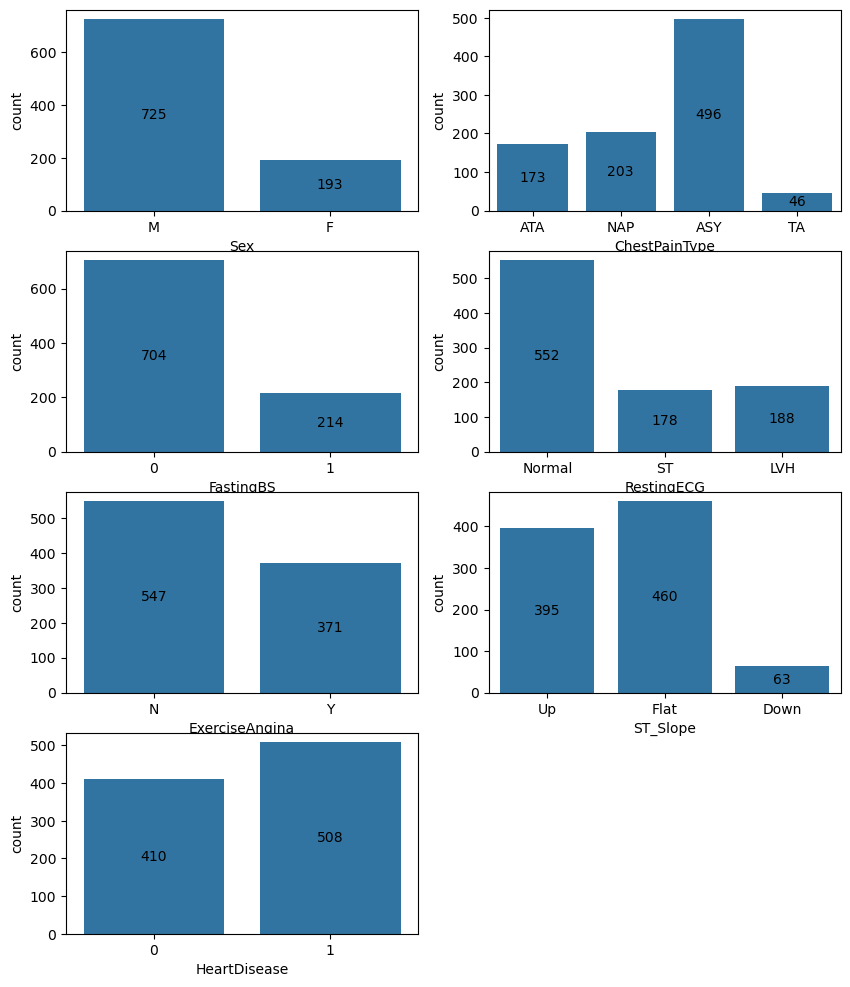

In [6]:
categorical_cols = ["Sex", "ChestPainType", "FastingBS", "RestingECG", "ExerciseAngina", "ST_Slope", "HeartDisease"]

fig = plt.figure(figsize=(10,12)) 

for idx, col in enumerate(categorical_cols):
  ax = plt.subplot(4, 2 , idx+1)
  sns.countplot(x=heart_df[col], ax=ax)
  # add data labels to each bar
  for container in ax.containers:
    ax.bar_label(container, label_type="center")
  


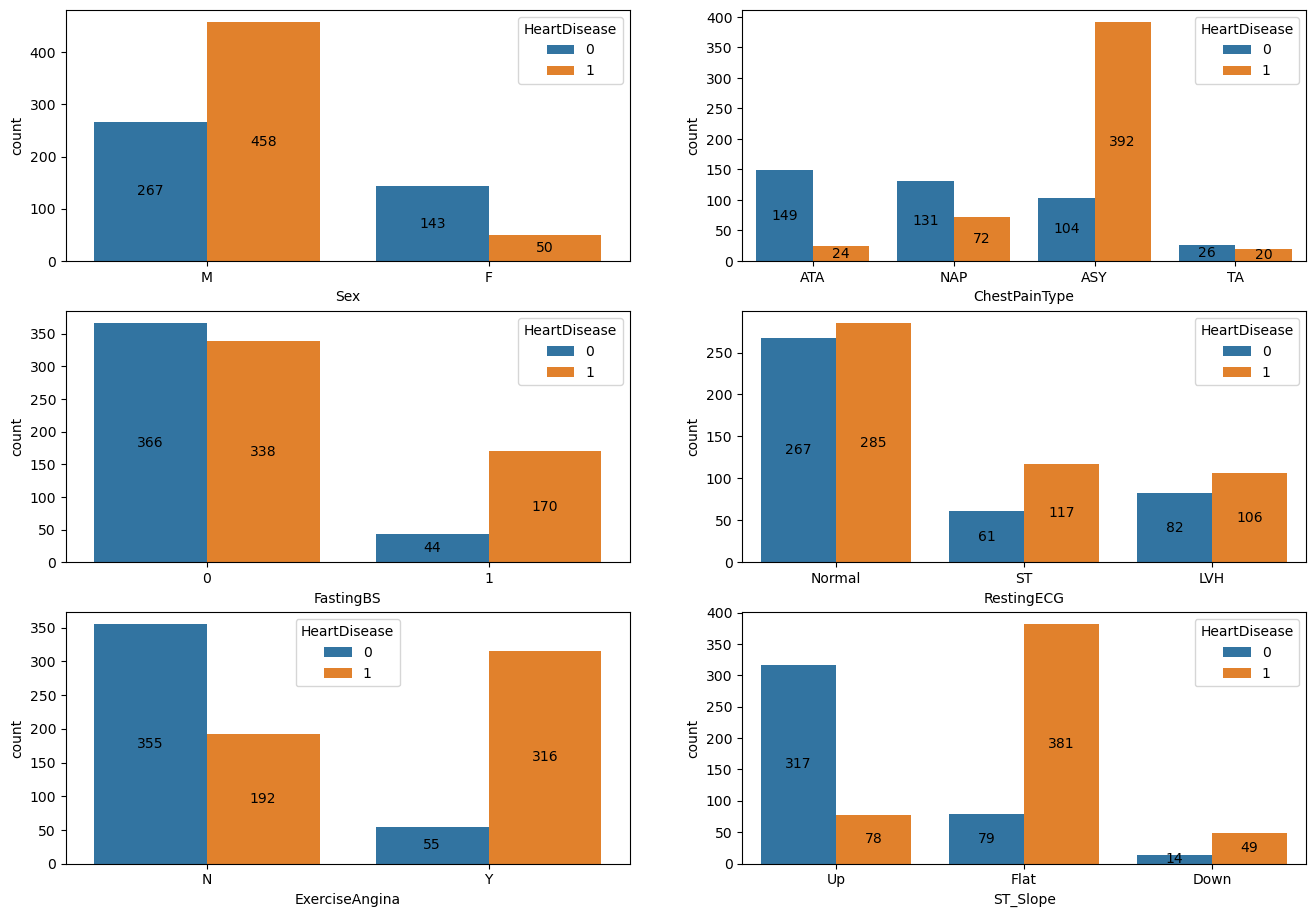

In [7]:
fig = plt.figure(figsize=(16,15))

for idx, col in enumerate(categorical_cols[:-1]):
    ax = plt.subplot(4,2, idx+1)
    #group by HeartDisease
    sns.countplot(x=heart_df[col], hue=heart_df["HeartDisease"], ax=ax)
    #add data labels to each bar 
    for container in ax.containers:
           ax.bar_label(container, label_type="center")

In [8]:
heart_df[heart_df['RestingBP']== 0].info()

<class 'pandas.core.frame.DataFrame'>
Index: 1 entries, 449 to 449
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             1 non-null      int64  
 1   Sex             1 non-null      object 
 2   ChestPainType   1 non-null      object 
 3   RestingBP       1 non-null      int64  
 4   Cholesterol     1 non-null      int64  
 5   FastingBS       1 non-null      int64  
 6   RestingECG      1 non-null      object 
 7   MaxHR           1 non-null      int64  
 8   ExerciseAngina  1 non-null      object 
 9   Oldpeak         1 non-null      float64
 10  ST_Slope        1 non-null      object 
 11  HeartDisease    1 non-null      int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 104.0+ bytes


In [9]:
heart_df[heart_df['Cholesterol']== 0].info()

<class 'pandas.core.frame.DataFrame'>
Index: 172 entries, 293 to 536
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             172 non-null    int64  
 1   Sex             172 non-null    object 
 2   ChestPainType   172 non-null    object 
 3   RestingBP       172 non-null    int64  
 4   Cholesterol     172 non-null    int64  
 5   FastingBS       172 non-null    int64  
 6   RestingECG      172 non-null    object 
 7   MaxHR           172 non-null    int64  
 8   ExerciseAngina  172 non-null    object 
 9   Oldpeak         172 non-null    float64
 10  ST_Slope        172 non-null    object 
 11  HeartDisease    172 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 17.5+ KB


In [10]:
#Limpieza de datos. Como Colesterol tiene mucho registros con valor cero, se realiza limpieza. RestingBp solo tiene un valor de cero, por lo que se quita ese registro

df_clean = heart_df.copy()

df_clean = df_clean[df_clean['RestingBP'] != 0] #eliminacion de datos donde la presion arterial es de cero

heartdisease_mask = df_clean["HeartDisease"]==0 #creacion de booleanos

cholesterol_without_heartdisease = df_clean.loc[heartdisease_mask, "Cholesterol"]  #Devuelve una columna que relaciona la variable colesterol y las que no tienen enfermedad del corazion

cholesterol_with_heartdisease = df_clean.loc[~heartdisease_mask, "Cholesterol"]

#para no eliminar la totalidad de registros que tienen el valor de 0 en colesterol se va a utilizar la media en los datos donde se relaciona el colesterol con enfermedad cardiaca y la media donde 
#relaciona el colestor con la no identificacion de enfermedad cardiaca

#df_clean.loc[heartdisease_mask, "Cholesterol"]

df_clean.loc[heartdisease_mask, "Cholesterol"] = cholesterol_without_heartdisease.replace(to_replace=0, value= cholesterol_without_heartdisease.median())

df_clean.loc[~heartdisease_mask, "Cholesterol"] = cholesterol_with_heartdisease.replace(to_replace=0, value= cholesterol_with_heartdisease.median())


In [11]:
df_clean[["Cholesterol", "RestingBP"]].describe()

,Cholesterol,RestingBP
count,917.000000,917.000000
mean,239.700109,132.540894
std,54.352727,17.999749
min,85.000000,80.000000
25%,214.000000,120.000000
50%,225.000000,130.000000
75%,267.000000,140.000000
max,603.000000,200.000000


In [12]:
#convierte las variables no cuantitativas en unos y ceros( true, false). One hot encoding
df_clean = pd.get_dummies(df_clean, drop_first=True) 

In [13]:
df_clean.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160,180,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130,283,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138,214,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150,195,0,122,0.0,0,True,False,True,False,True,False,False,False,True


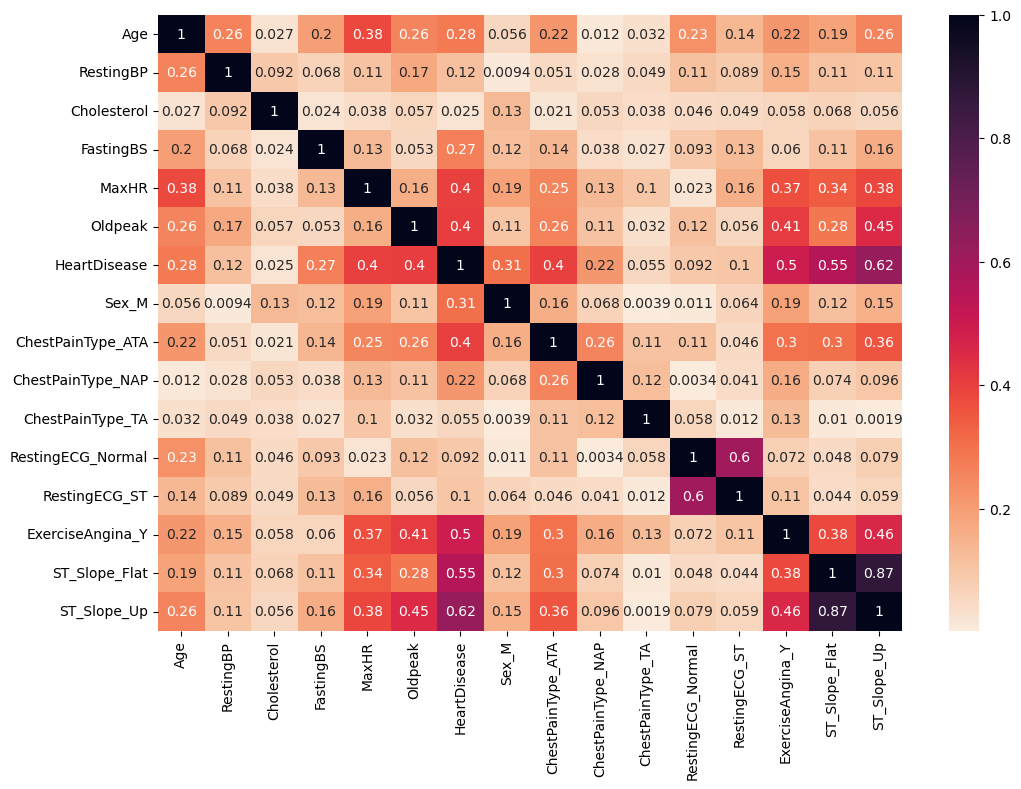

In [14]:
correlations = abs(df_clean.corr()) #correlacion de pearson, correlacion lineal entre variables
plt.figure(figsize=(12,8))
sns.heatmap(correlations, annot=True, cmap="rocket_r")
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

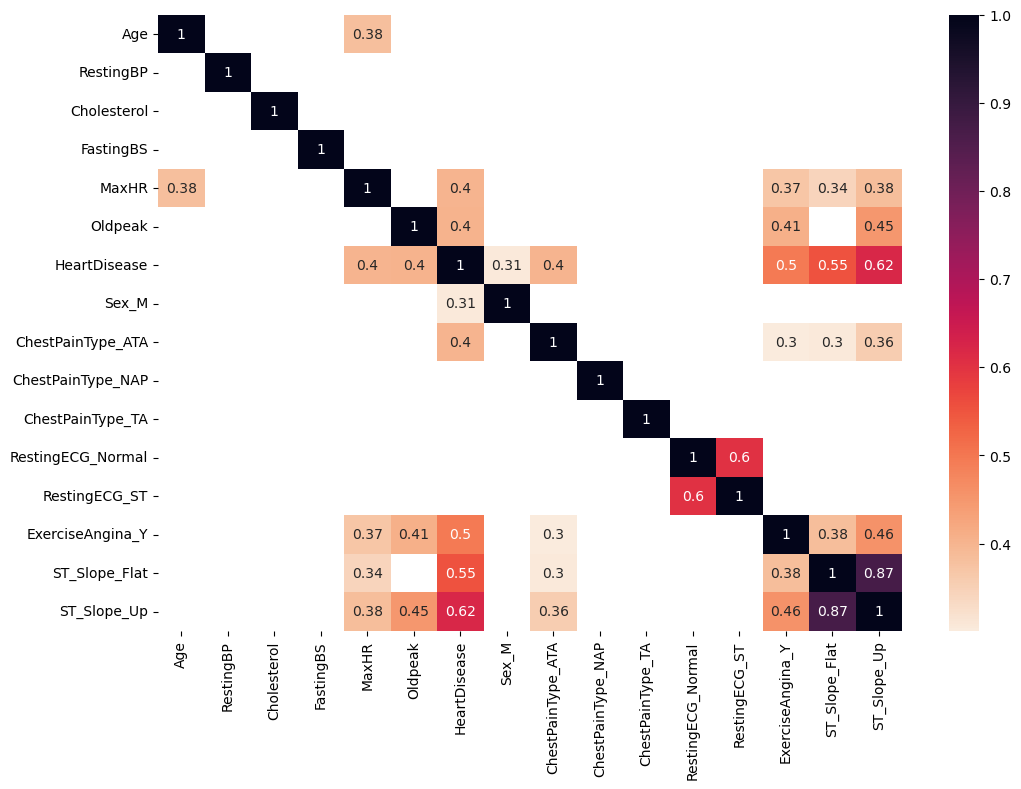

In [15]:
#filtrar correlaciones mayores a 0.30

plt.figure(figsize=(12,8))
sns.heatmap(correlations[correlations > 0.30], annot=True, cmap="rocket_r")
plt.show

In [16]:
#diviendo el dataset 
X = df_clean.drop(["HeartDisease"], axis=1) #eliminacion de la columna heart disease del dataset
y = df_clean["HeartDisease"] # almacena solo la columna heart disease

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.15, random_state=417) #division del dataset en donde el 15% del total de los datos va a ser usado mas adelante para
#la evaluacion. random_state es la semilla de aleatoridad


features = [
    "MaxHR",
    "Oldpeak",
    "Sex_M",
    "ExerciseAngina_Y",
    "ST_Slope_Flat",
    "ST_Slope_Up"
]  #seleccion de aquellas variables que tienen mayor correlacion

for feature in features:
    knn = KNeighborsClassifier(n_neighbors = 3) #Establecer k neighbors
    knn.fit(X_train[[feature]], y_train)  #ajusta el k-neighbor con los datos de entrenamiento
    accuracy = knn.score(X_val[[feature]], y_val) #retorna la precision comparando los datos a evaluar y su resultado
    print(f"The k-NN classifier trained on {feature} and with k = 3 has an accuracy of {(accuracy*100):.2f} %") #precision individual para saber si se tiene enfermedad cardiaca 
    


The k-NN classifier trained on MaxHR and with k = 3 has an accuracy of 66.67 %
The k-NN classifier trained on Oldpeak and with k = 3 has an accuracy of 76.81 %
The k-NN classifier trained on Sex_M and with k = 3 has an accuracy of 44.93 %
The k-NN classifier trained on ExerciseAngina_Y and with k = 3 has an accuracy of 73.19 %
The k-NN classifier trained on ST_Slope_Flat and with k = 3 has an accuracy of 81.88 %
The k-NN classifier trained on ST_Slope_Up and with k = 3 has an accuracy of 84.06 %


In [17]:
#buscando mejorar el modelo

scaler = MinMaxScaler() 
X_train_scaled = scaler.fit_transform(X_train[features]) #transformar los valores para que queden entre cero y uno. aprende y escala
X_val_scaled = scaler.transform(X_val[features]) #solo escala. Usa los parametros aprendidos del entrenamiento
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_scaled, y_train)
accuracy = knn.score(X_val_scaled, y_val)
print(f"Accuracy: {accuracy*100:2f}") #precision genera


Accuracy: 83.333333


In [47]:
X = df_clean.drop(["HeartDisease"], axis = 1) #eliminacion de la columna HeartDisease
y = df_clean["HeartDisease"] #columna a predecir

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=417)

features = [
    "MaxHR",
    "Oldpeak",
    "Sex_M",
    "ExerciseAngina_Y",
    "ST_Slope_Flat",
    "ST_Slope_Up"
]

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train[features]) #aprende y escala
X_train_scaled

array([[0.78169014, 0.42682927, 0.        , 0.        , 0.        ,
        1.        ],
       [0.46478873, 0.42682927, 1.        , 1.        , 1.        ,
        0.        ],
       [0.71126761, 0.48780488, 0.        , 0.        , 1.        ,
        0.        ],
       ...,
       [0.26056338, 0.51219512, 1.        , 1.        , 0.        ,
        1.        ],
       [0.15492958, 0.19512195, 1.        , 0.        , 0.        ,
        1.        ],
       [0.59859155, 0.63414634, 1.        , 0.        , 1.        ,
        0.        ]])

In [51]:

#optimizacion de parametros
grid_params = {"n_neighbors": range(1,20),
                "metric": ["minkowski", "manhattan"]
              } #diccionario para probar diferentes configuraciones correspondientes a n_neighbors y calculo de distancias

knn = KNeighborsClassifier()
knn_grid = GridSearchCV(knn, grid_params, scoring="accuracy") #busqueda exhaustiva en donde se usan los parametros de grid_params para saber cual el mejor 
knn_grid.fit(X_train_scaled, y_train);

In [52]:
knn_grid.best_score_*100, knn_grid.best_params_,

(84.07692307692308, {'metric': 'minkowski', 'n_neighbors': 18})

In [53]:
X_test_scaled = scaler.transform(X_test[features]) #escalar los datos del entrenamiento
predictions = knn_grid.best_estimator_.predict(X_test_scaled) #uso del mejor estimador(manhattan, neighbhorn=19) para predecir los datos de prueba y saber si se tiene o no enfermedad cardiaca
accuracy = accuracy_score(y_test, predictions) # compara los datos de la prediccion con los reales
print(f" Model Accuracy on test set: {accuracy*100:.2f}")

 Model Accuracy on test set: 82.61
